In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("vehicle_price_prediction.csv")
df.head()

,make,model,year,mileage,engine_hp,transmission,fuel_type,drivetrain,body_type,exterior_color,interior_color,owner_count,accident_history,seller_type,condition,trim,vehicle_age,mileage_per_year,brand_popularity,price
0,Volkswagen,Jetta,2016,183903,173,Manual,Electric,RWD,Sedan,Blue,Brown,5,NaN,Dealer,Excellent,EX,9,20433.666667,0.040054,7208.52
1,Lexus,RX,2010,236643,352,Manual,Gasoline,FWD,Sedan,Silver,Beige,5,Minor,Dealer,Good,LX,15,15776.200000,0.039921,6911.81
2,Subaru,Crosstrek,2016,103199,188,Automatic,Diesel,AWD,Sedan,Silver,Beige,5,NaN,Dealer,Excellent,Touring,9,11466.555556,0.040230,11915.63
3,Cadillac,Lyriq,2016,118889,338,Manual,Gasoline,AWD,SUV,Black,Gray,3,NaN,Private,Good,Base,9,13209.888889,0.039847,25984.79
4,Toyota,Highlander,2018,204170,196,Manual,Diesel,FWD,Sedan,Red,Brown,5,Minor,Dealer,Excellent,Sport,7,29167.142857,0.039627,8151.30


In [3]:
df.shape
df.columns

Index(['make', 'model', 'year', 'mileage', 'engine_hp', 'transmission',
       'fuel_type', 'drivetrain', 'body_type', 'exterior_color',
       'interior_color', 'owner_count', 'accident_history', 'seller_type',
       'condition', 'trim', 'vehicle_age', 'mileage_per_year',
       'brand_popularity', 'price'],
      dtype='str')

In [4]:
train_df = df.iloc[0:70001]
val_df = df.iloc[70001:85001]
test_df = df.iloc[85001:]

print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Training: (70001, 20)
Validation: (15000, 20)
Test: (914999, 20)


In [5]:
df["condition"].value_counts()

condition
Good         499683
Excellent    400373
Fair          99944
Name: count, dtype: int64

In [6]:
def gini_impurity(y, n_classes):
    counts = np.bincount(y, minlength=n_classes)
    probabilities = counts / len(y)
    return 1 - np.sum(probabilities ** 2)


def accuracy(y_true, y_pred):
    return np.mean(np.array(y_true) == np.array(y_pred))


In [7]:
class DecisionTreeScratch:
    def __init__(self, max_depth=8, min_samples_leaf=5, max_features=None, random_state=None):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.random_state = random_state
        self.rng = np.random.default_rng(random_state)

    def fit(self, X, y):
        self.features = sorted(list(X.columns))  # alphabetical order for tie-breaking
        self.classes = sorted(pd.Series(y).unique())
        self.class_to_int = {c: i for i, c in enumerate(self.classes)}
        self.int_to_class = {i: c for c, i in self.class_to_int.items()}
        self.n_classes = len(self.classes)

        y_encoded = pd.Series(y).map(self.class_to_int).to_numpy()

        self.feature_types = {}
        self.fill_values = {}

        X_fixed = X.copy()

        for col in self.features:
            if pd.api.types.is_numeric_dtype(X_fixed[col]):
                self.feature_types[col] = "numeric"
                fill_value = X_fixed[col].median()
                self.fill_values[col] = fill_value
                X_fixed[col] = X_fixed[col].fillna(fill_value).astype(float)
            else:
                self.feature_types[col] = "categorical"
                self.fill_values[col] = "__MISSING__"
                X_fixed[col] = X_fixed[col].fillna("__MISSING__").astype(str)

        self.tree = self._build_tree(X_fixed, y_encoded, depth=0)
        return self

    def _majority_class(self, y):
        counts = np.bincount(y, minlength=self.n_classes)
        return np.argmax(counts)

    def _choose_features(self):
        if self.max_features is None:
            return self.features

        if self.max_features == "sqrt":
            k = max(1, int(np.sqrt(len(self.features))))
        elif isinstance(self.max_features, int):
            k = min(self.max_features, len(self.features))
        else:
            k = len(self.features)

        chosen = self.rng.choice(self.features, size=k, replace=False)
        return sorted(chosen)

    def _best_split(self, X, y):
        parent_gini = gini_impurity(y, self.n_classes)

        best_gain = 0
        best_feature = None
        best_value = None
        best_is_numeric = None
        best_left_mask = None

        for feature in self._choose_features():
            values = X[feature].to_numpy()

            if self.feature_types[feature] == "numeric":
                order = np.argsort(values)
                sorted_values = values[order]

                for i in range(self.min_samples_leaf - 1, len(y) - self.min_samples_leaf):
                    if sorted_values[i] == sorted_values[i + 1]:
                        continue

                    threshold = (sorted_values[i] + sorted_values[i + 1]) / 2

                    left_mask = values <= threshold
                    right_mask = ~left_mask

                    if left_mask.sum() < self.min_samples_leaf:
                        continue

                    if right_mask.sum() < self.min_samples_leaf:
                        continue

                    left_gini = gini_impurity(y[left_mask], self.n_classes)
                    right_gini = gini_impurity(y[right_mask], self.n_classes)

                    weighted_gini = (
                        left_mask.sum() / len(y) * left_gini
                        + right_mask.sum() / len(y) * right_gini
                    )

                    gain = parent_gini - weighted_gini

                    if gain > best_gain:
                        best_gain = gain
                        best_feature = feature
                        best_value = threshold
                        best_is_numeric = True
                        best_left_mask = left_mask

            else:
                categories = sorted(pd.Series(values).unique())

                for category in categories:
                    left_mask = values == category
                    right_mask = ~left_mask

                    if left_mask.sum() < self.min_samples_leaf:
                        continue

                    if right_mask.sum() < self.min_samples_leaf:
                        continue

                    left_gini = gini_impurity(y[left_mask], self.n_classes)
                    right_gini = gini_impurity(y[right_mask], self.n_classes)

                    weighted_gini = (
                        left_mask.sum() / len(y) * left_gini
                        + right_mask.sum() / len(y) * right_gini
                    )

                    gain = parent_gini - weighted_gini

                    if gain > best_gain:
                        best_gain = gain
                        best_feature = feature
                        best_value = category
                        best_is_numeric = False
                        best_left_mask = left_mask

        if best_feature is None:
            return None

        return best_feature, best_value, best_is_numeric, best_left_mask, best_gain

    def _build_tree(self, X, y, depth):
        prediction = self._majority_class(y)

        if len(np.unique(y)) == 1:
            return {"type": "leaf", "prediction": prediction}

        if self.max_depth is not None and depth >= self.max_depth:
            return {"type": "leaf", "prediction": prediction}

        if len(y) < 2 * self.min_samples_leaf:
            return {"type": "leaf", "prediction": prediction}

        split = self._best_split(X, y)

        if split is None:
            return {"type": "leaf", "prediction": prediction}

        feature, value, is_numeric, left_mask, gain = split

        if gain <= 0:
            return {"type": "leaf", "prediction": prediction}

        right_mask = ~left_mask

        return {
            "type": "node",
            "feature": feature,
            "value": value,
            "is_numeric": is_numeric,
            "left": self._build_tree(X[left_mask], y[left_mask], depth + 1),
            "right": self._build_tree(X[right_mask], y[right_mask], depth + 1)
        }

    def _prepare_X(self, X):
        X_fixed = X.copy()

        for col in self.features:
            if self.feature_types[col] == "numeric":
                X_fixed[col] = X_fixed[col].fillna(self.fill_values[col]).astype(float)
            else:
                X_fixed[col] = X_fixed[col].fillna("__MISSING__").astype(str)

        return X_fixed[self.features]

    def _predict_one(self, row, node):
        if node["type"] == "leaf":
            return self.int_to_class[node["prediction"]]

        feature = node["feature"]

        if node["is_numeric"]:
            if row[feature] <= node["value"]:
                return self._predict_one(row, node["left"])
            return self._predict_one(row, node["right"])

        if row[feature] == node["value"]:
            return self._predict_one(row, node["left"])
        return self._predict_one(row, node["right"])

    def predict(self, X):
        X_fixed = self._prepare_X(X)
        predictions = []

        for _, row in X_fixed.iterrows():
            predictions.append(self._predict_one(row, self.tree))

        return np.array(predictions)

In [8]:
target_col = "condition"

X_train = train_df.drop(columns=["condition", "price"])
y_train = train_df[target_col]

X_val = val_df.drop(columns=["condition", "price"])
y_val = val_df[target_col]

X_test = test_df.drop(columns=["condition", "price"])
y_test = test_df[target_col]

dt_model = DecisionTreeScratch(
    max_depth=8,
    min_samples_leaf=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_val_pred = dt_model.predict(X_val)

print("Decision Tree Validation Accuracy:", accuracy(y_val, dt_val_pred))

Decision Tree Validation Accuracy: 0.4961333333333333


In [9]:
class RandomForestClassifierScratch:
    def __init__(self, n_estimators=3, max_depth=8, min_samples_leaf=5,
                 max_features="sqrt", sample_ratio=0.7, random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.sample_ratio = sample_ratio
        self.random_state = random_state
        self.rng = np.random.default_rng(random_state)
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        n_samples = len(X)
        sample_size = int(n_samples * self.sample_ratio)

        for i in range(self.n_estimators):
            sample_indices = self.rng.choice(
                n_samples,
                size=sample_size,
                replace=True
            )

            X_sample = X.iloc[sample_indices]
            y_sample = y.iloc[sample_indices]

            tree = DecisionTreeScratch(
                max_depth=self.max_depth,
                min_samples_leaf=self.min_samples_leaf,
                max_features=self.max_features,
                random_state=self.random_state + i
            )

            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

            print(f"Finished tree {i + 1}/{self.n_estimators}")

        return self

    def predict(self, X):
        all_predictions = np.array([tree.predict(X) for tree in self.trees])

        final_predictions = []

        for predictions_for_one_row in all_predictions.T:
            values, counts = np.unique(predictions_for_one_row, return_counts=True)
            final_predictions.append(values[np.argmax(counts)])

        return np.array(final_predictions)

In [10]:
rf_classifier = RandomForestClassifierScratch(
    n_estimators=3,
    max_depth=8,
    min_samples_leaf=5,
    max_features="sqrt",
    sample_ratio=0.7,
    random_state=42
)

rf_classifier.fit(X_train, y_train)

rf_val_pred = rf_classifier.predict(X_val)

print("Random Forest Classifier Validation Accuracy:", accuracy(y_val, rf_val_pred))


Finished tree 1/3
Finished tree 2/3
Finished tree 3/3
Random Forest Classifier Validation Accuracy: 0.49833333333333335


In [11]:
def ssr(y):
    y = np.array(y, dtype=float)
    mean_y = np.mean(y)
    return np.sum((y - mean_y) ** 2)


def mse(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    return np.mean((y_true - y_pred) ** 2)

In [12]:
class DecisionTreeRegressorScratch:
    def __init__(self, max_depth=8, min_samples_leaf=5, max_features=None,
                 max_thresholds=40, random_state=None):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.max_thresholds = max_thresholds
        self.random_state = random_state
        self.rng = np.random.default_rng(random_state)

    def fit(self, X, y):
        # Sort features alphabetically for tie-breaking
        self.features = sorted(list(X.columns))

        self.feature_types = {}
        self.fill_values = {}

        X_fixed = X.copy()
        y_fixed = pd.Series(y).astype(float).to_numpy()

        for col in self.features:
            if pd.api.types.is_numeric_dtype(X_fixed[col]):
                self.feature_types[col] = "numeric"
                fill_value = X_fixed[col].median()
                self.fill_values[col] = fill_value
                X_fixed[col] = X_fixed[col].fillna(fill_value).astype(float)
            else:
                self.feature_types[col] = "categorical"
                self.fill_values[col] = "__MISSING__"
                X_fixed[col] = X_fixed[col].fillna("__MISSING__").astype(str)

        self.tree = self._build_tree(X_fixed, y_fixed, depth=0)
        return self

    def _leaf_value(self, y):
        return np.mean(y)

    def _choose_features(self):
        if self.max_features is None:
            return self.features

        if self.max_features == "sqrt":
            k = max(1, int(np.sqrt(len(self.features))))
        elif isinstance(self.max_features, int):
            k = min(self.max_features, len(self.features))
        else:
            k = len(self.features)

        chosen = self.rng.choice(self.features, size=k, replace=False)
        return sorted(chosen)

    def _numeric_thresholds(self, values):
        unique_values = np.unique(values)

        if len(unique_values) <= 1:
            return []

        thresholds = (unique_values[:-1] + unique_values[1:]) / 2

        # To reduce runtime on large data
        if len(thresholds) > self.max_thresholds:
            percentiles = np.linspace(0, 100, self.max_thresholds + 2)[1:-1]
            thresholds = np.percentile(values, percentiles)
            thresholds = np.unique(thresholds)

        return thresholds

    def _best_split(self, X, y):
        parent_ssr = ssr(y)

        best_gain = 0
        best_feature = None
        best_value = None
        best_is_numeric = None
        best_left_mask = None

        for feature in self._choose_features():
            values = X[feature].to_numpy()

            if self.feature_types[feature] == "numeric":
                thresholds = self._numeric_thresholds(values)

                for threshold in thresholds:
                    left_mask = values <= threshold
                    right_mask = ~left_mask

                    if left_mask.sum() < self.min_samples_leaf:
                        continue

                    if right_mask.sum() < self.min_samples_leaf:
                        continue

                    left_y = y[left_mask]
                    right_y = y[right_mask]

                    child_ssr = ssr(left_y) + ssr(right_y)
                    gain = parent_ssr - child_ssr

                    # Strict > keeps the first alphabetical feature in case of tie
                    if gain > best_gain:
                        best_gain = gain
                        best_feature = feature
                        best_value = threshold
                        best_is_numeric = True
                        best_left_mask = left_mask

            else:
                categories = sorted(pd.Series(values).unique())

                for category in categories:
                    left_mask = values == category
                    right_mask = ~left_mask

                    if left_mask.sum() < self.min_samples_leaf:
                        continue

                    if right_mask.sum() < self.min_samples_leaf:
                        continue

                    left_y = y[left_mask]
                    right_y = y[right_mask]

                    child_ssr = ssr(left_y) + ssr(right_y)
                    gain = parent_ssr - child_ssr

                    # Strict > keeps the first alphabetical feature in case of tie
                    if gain > best_gain:
                        best_gain = gain
                        best_feature = feature
                        best_value = category
                        best_is_numeric = False
                        best_left_mask = left_mask

        if best_feature is None:
            return None

        return best_feature, best_value, best_is_numeric, best_left_mask, best_gain

    def _build_tree(self, X, y, depth):
        prediction = self._leaf_value(y)

        if self.max_depth is not None and depth >= self.max_depth:
            return {"type": "leaf", "prediction": prediction}

        if len(y) < 2 * self.min_samples_leaf:
            return {"type": "leaf", "prediction": prediction}

        split = self._best_split(X, y)

        if split is None:
            return {"type": "leaf", "prediction": prediction}

        feature, value, is_numeric, left_mask, gain = split

        if gain <= 0:
            return {"type": "leaf", "prediction": prediction}

        right_mask = ~left_mask

        return {
            "type": "node",
            "feature": feature,
            "value": value,
            "is_numeric": is_numeric,
            "left": self._build_tree(X[left_mask], y[left_mask], depth + 1),
            "right": self._build_tree(X[right_mask], y[right_mask], depth + 1)
        }

    def _prepare_X(self, X):
        X_fixed = X.copy()

        for col in self.features:
            if self.feature_types[col] == "numeric":
                X_fixed[col] = X_fixed[col].fillna(self.fill_values[col]).astype(float)
            else:
                X_fixed[col] = X_fixed[col].fillna("__MISSING__").astype(str)

        return X_fixed[self.features]

    def _predict_one(self, row, node):
        if node["type"] == "leaf":
            return node["prediction"]

        feature = node["feature"]

        if node["is_numeric"]:
            if row[feature] <= node["value"]:
                return self._predict_one(row, node["left"])
            return self._predict_one(row, node["right"])

        if row[feature] == node["value"]:
            return self._predict_one(row, node["left"])
        return self._predict_one(row, node["right"])

    def predict(self, X):
        X_fixed = self._prepare_X(X)
        predictions = []

        for _, row in X_fixed.iterrows():
            predictions.append(self._predict_one(row, self.tree))

        return np.array(predictions)

In [13]:
target_col = "price"

X_train_reg = train_df.drop(columns=["condition", "price"])
y_train_reg = train_df[target_col]

X_val_reg = val_df.drop(columns=["condition", "price"])
y_val_reg = val_df[target_col]

X_test_reg = test_df.drop(columns=["condition", "price"])
y_test_reg = test_df[target_col]

dt_regressor = DecisionTreeRegressorScratch(
    max_depth=8,
    min_samples_leaf=5,
    max_thresholds=40,
    random_state=42
)

dt_regressor.fit(X_train_reg, y_train_reg)

dt_reg_val_pred = dt_regressor.predict(X_val_reg)

print("Decision Tree Regressor Validation MSE:", mse(y_val_reg, dt_reg_val_pred))


Decision Tree Regressor Validation MSE: 11050001.651596187


In [14]:
class RandomForestRegressorScratch:
    def __init__(self, n_estimators=3, max_depth=8, min_samples_leaf=5,
                 max_features="sqrt", sample_ratio=0.7, max_thresholds=40,
                 random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.sample_ratio = sample_ratio
        self.max_thresholds = max_thresholds
        self.random_state = random_state
        self.rng = np.random.default_rng(random_state)
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        n_samples = len(X)
        sample_size = int(n_samples * self.sample_ratio)

        for i in range(self.n_estimators):
            sample_indices = self.rng.choice(
                n_samples,
                size=sample_size,
                replace=True
            )

            X_sample = X.iloc[sample_indices]
            y_sample = y.iloc[sample_indices]

            tree = DecisionTreeRegressorScratch(
                max_depth=self.max_depth,
                min_samples_leaf=self.min_samples_leaf,
                max_features=self.max_features,
                max_thresholds=self.max_thresholds,
                random_state=self.random_state + i
            )

            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

            print(f"Finished regressor tree {i + 1}/{self.n_estimators}")

        return self

    def predict(self, X):
        all_predictions = np.array([tree.predict(X) for tree in self.trees])

        # Required for Random Forest Regressor:
        # final prediction = average of all trees' predictions
        return np.mean(all_predictions, axis=0)

### Runtime Optimization

To improve runtime efficiency, threshold sampling was used instead of checking all possible thresholds for every numeric feature.

Specifically, the implementation limits the number of checked thresholds using:
`max_thresholds = 40`

This optimization reduces training time while still maintaining good model performance.

In [15]:
rf_regressor = RandomForestRegressorScratch(
    n_estimators=3,
    max_depth=8,
    min_samples_leaf=5,
    max_features="sqrt",
    sample_ratio=0.7,
    max_thresholds=40,
    random_state=42
)

rf_regressor.fit(X_train_reg, y_train_reg)

rf_reg_val_pred = rf_regressor.predict(X_val_reg)

rf_reg_mse = mse(y_val_reg, rf_reg_val_pred)
rf_reg_rmse = np.sqrt(rf_reg_mse)

print("Random Forest Regressor Validation MSE:", rf_reg_mse)
print("Random Forest Regressor Validation RMSE:", rf_reg_rmse)

Finished regressor tree 1/3
Finished regressor tree 2/3
Finished regressor tree 3/3
Random Forest Regressor Validation MSE: 14537039.973467829
Random Forest Regressor Validation RMSE: 3812.747037697076


In [16]:
print("========== Section A Summary ==========")
print("Decision Tree Classifier Validation Accuracy:", accuracy(y_val, dt_val_pred))
print("Random Forest Classifier Validation Accuracy:", accuracy(y_val, rf_val_pred))

dt_reg_mse = mse(y_val_reg, dt_reg_val_pred)
dt_reg_rmse = np.sqrt(dt_reg_mse)

print("Decision Tree Regressor Validation MSE:", dt_reg_mse)
print("Decision Tree Regressor Validation RMSE:", dt_reg_rmse)

print("Random Forest Regressor Validation MSE:", rf_reg_mse)
print("Random Forest Regressor Validation RMSE:", rf_reg_rmse)


# ======== Test Evaluation ========

# Classification Test
dt_test_pred = dt_model.predict(X_test)
rf_test_pred = rf_classifier.predict(X_test)

print("Decision Tree Classifier Test Accuracy:",
      accuracy(y_test, dt_test_pred))

print("Random Forest Classifier Test Accuracy:",
      accuracy(y_test, rf_test_pred))


# Regression Test
dt_reg_test_pred = dt_regressor.predict(X_test_reg)
rf_reg_test_pred = rf_regressor.predict(X_test_reg)

dt_test_mse = mse(y_test_reg, dt_reg_test_pred)
rf_test_mse = mse(y_test_reg, rf_reg_test_pred)

print("Decision Tree Regressor Test MSE:", dt_test_mse)
print("Decision Tree Regressor Test RMSE:", np.sqrt(dt_test_mse))

print("Random Forest Regressor Test MSE:", rf_test_mse)
print("Random Forest Regressor Test RMSE:", np.sqrt(rf_test_mse))

========== Section A Summary ==========
Decision Tree Classifier Validation Accuracy: 0.4961333333333333
Random Forest Classifier Validation Accuracy: 0.49833333333333335
Decision Tree Regressor Validation MSE: 11050001.651596187
Decision Tree Regressor Validation RMSE: 3324.1542761424575
Random Forest Regressor Validation MSE: 14537039.973467829
Random Forest Regressor Validation RMSE: 3812.747037697076
Decision Tree Classifier Test Accuracy: 0.494886879657792
Random Forest Classifier Test Accuracy: 0.49831967029472163
Decision Tree Regressor Test MSE: 11009517.187611856
Decision Tree Regressor Test RMSE: 3318.0592501659544
Random Forest Regressor Test MSE: 14525677.085092334
Random Forest Regressor Test RMSE: 3811.2566280811284


### Section B - Data Preparation

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
original_df = df.copy()

In [19]:
print("Missing values before handling:")
print(original_df.isnull().sum())

print("Total missing values:")
print(original_df.isnull().sum().sum())

Missing values before handling:
make                     0
model                    0
year                     0
mileage                  0
engine_hp                0
transmission             0
fuel_type                0
drivetrain               0
body_type                0
exterior_color           0
interior_color           0
owner_count              0
accident_history    750133
seller_type              0
condition                0
trim                     0
vehicle_age              0
mileage_per_year         0
brand_popularity         0
price                    0
dtype: int64
Total missing values:
750133


In [20]:
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

### Missing Values Handling

Numerical features were filled using the median because it is robust to outliers.

Categorical features were filled using the mode since it represents the most common category.

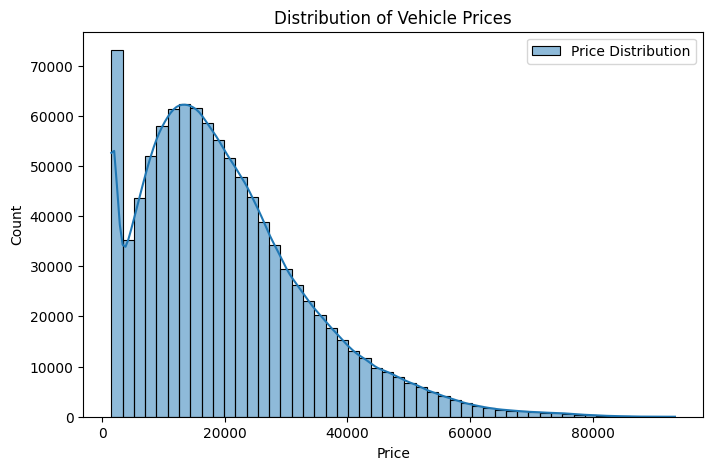

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=50, kde=True,
             label="Price Distribution")

plt.legend()
plt.title("Distribution of Vehicle Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

This histogram was selected to visualize the distribution of vehicle prices and detect skewness and possible outliers.
The plot shows that the price distribution is right-skewed, meaning that most vehicles are listed at relatively low prices while a smaller number of vehicles have very high prices.

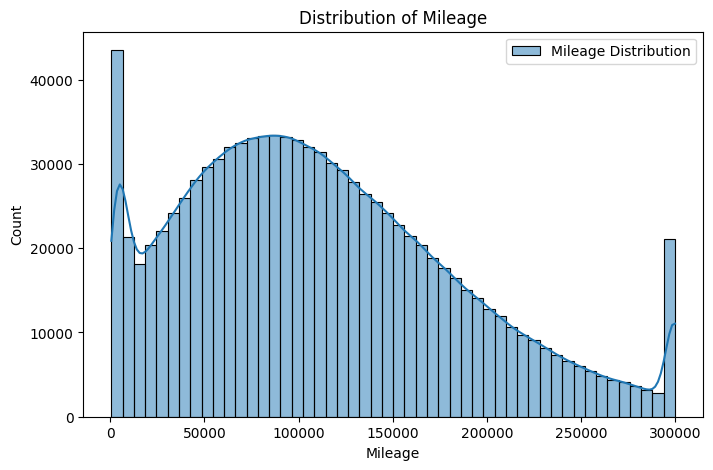

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["mileage"],
    bins=50,
    kde=True,
    label="Mileage Distribution"
)

plt.legend()
plt.title("Distribution of Mileage")
plt.xlabel("Mileage")
plt.ylabel("Count")

plt.show()

This histogram was selected to visualize the mileage distribution and detect repeated values and possible anomalies.
The graph reveals a concentration of repeated mileage values around 300000 km,
which may indicate rounded values or data acquisition artifacts.

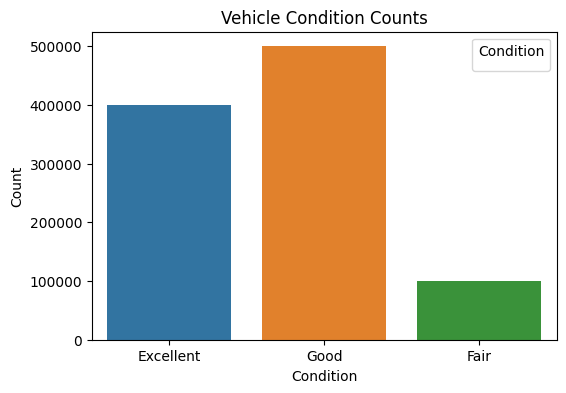

In [34]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x=df["condition"],
    hue=df["condition"]
)

plt.title("Vehicle Condition Counts")
plt.xlabel("Condition")
plt.ylabel("Count")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Condition")

plt.show()


This countplot was used to inspect the balance between the target classes.

In [24]:
Q1_price = df["price"].quantile(0.25)
Q3_price = df["price"].quantile(0.75)

IQR_price = Q3_price - Q1_price

lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

price_outliers = df[(df["price"] < lower_price) |
                    (df["price"] > upper_price)]

print("Price outliers:", len(price_outliers))


Price outliers: 25524


In [25]:
Q1_mileage = df["mileage"].quantile(0.25)
Q3_mileage = df["mileage"].quantile(0.75)

IQR_mileage = Q3_mileage - Q1_mileage

lower_mileage = Q1_mileage - 1.5 * IQR_mileage
upper_mileage = Q3_mileage + 1.5 * IQR_mileage

mileage_outliers = df[(df["mileage"] < lower_mileage) |
                      (df["mileage"] > upper_mileage)]

print("Mileage outliers:", len(mileage_outliers))

Mileage outliers: 0


### Artifact Analysis

The price column contains a floor effect where many values are exactly 1500 USD.

Additionally, mileage contains repeated values such as 300000 km, which may indicate rounded values or data acquisition artifacts.

These values were not removed because they may still represent real vehicles and removing them could distort the dataset distribution.

In [26]:
price_1500_count = (df["price"] == 1500).sum()

price_1500_percent = (
    price_1500_count / len(df)
) * 100

print("Vehicles priced exactly 1500:",
      price_1500_count)

print("Percentage:",
      round(price_1500_percent, 2), "%")

Vehicles priced exactly 1500: 46984
Percentage: 4.7 %


In [27]:
mileage_300k_count = (
    df["mileage"] == 300000
).sum()

mileage_300k_percent = (
    mileage_300k_count / len(df)
) * 100

print("Vehicles with mileage 300000:",
      mileage_300k_count)

print("Percentage:",
      round(mileage_300k_percent, 2), "%")

Vehicles with mileage 300000: 18534
Percentage: 1.85 %


### Outlier Threshold Justification

The IQR method was selected because it is robust to skewed distributions and extreme values.

Outliers were identified using the standard 1.5 × IQR rule.

The detected outliers were inspected manually before deciding whether to remove them. Most were kept because they likely represent real market values rather than invalid observations.

Removing these entries did not significantly change the overall distribution
of the dataset, therefore most observations were retained.


    

### Section C - Implementation & Complexity

In [1]:
train_mse = []
val_mse = []

depths = range(1, 21)

for depth in depths:

    dt_reg_model = DecisionTreeScratch(
        max_depth=depth,
        min_samples_leaf=5
    )

    dt_reg_model.fit(X_train, y_train_reg)

    train_pred = dt_reg_model.predict(X_train)
    val_pred = dt_reg_model.predict(X_val)

    train_mse.append(
        mse(y_train_reg, train_pred)
    )

    val_mse.append(
        mse(y_val_reg, val_pred)
    )

NameError: name 'DecisionTreeScratch' is not defined

مرحبااا الاء كيف الحال

שלוווווווםםםםם הייי
